Client Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter

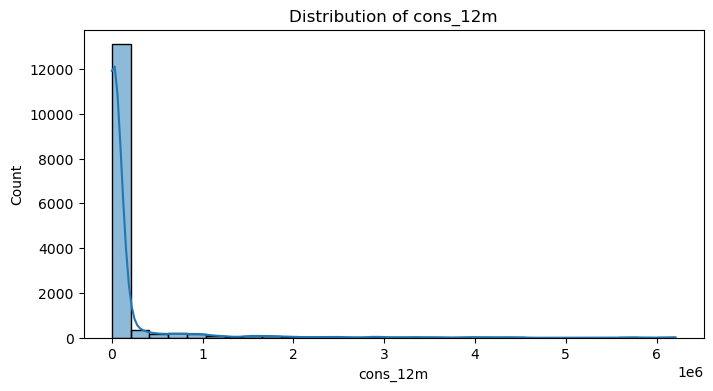

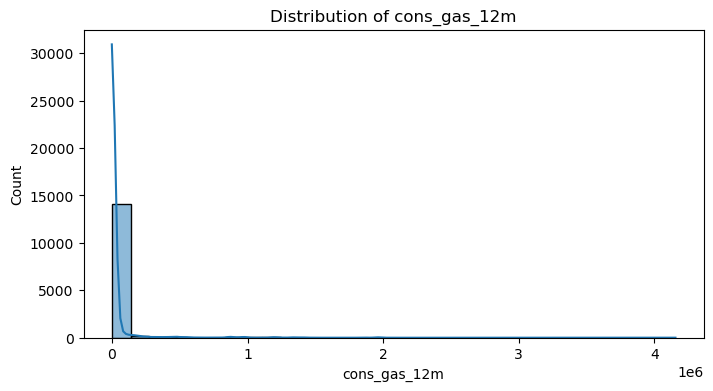

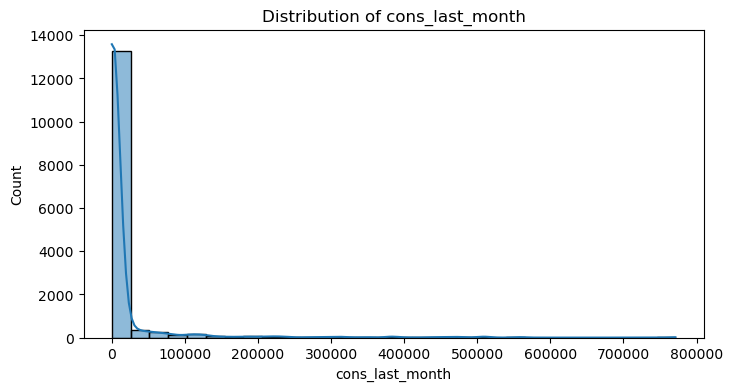

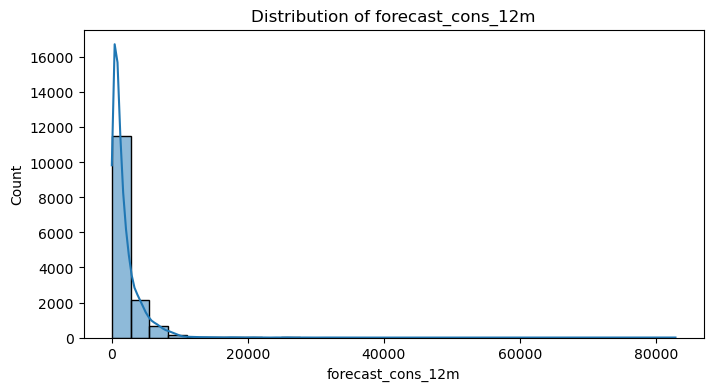

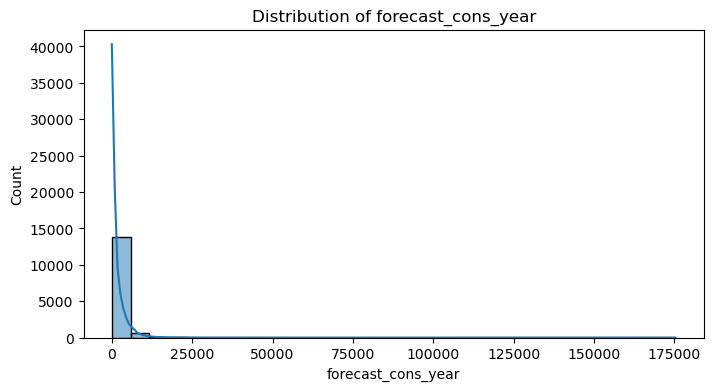

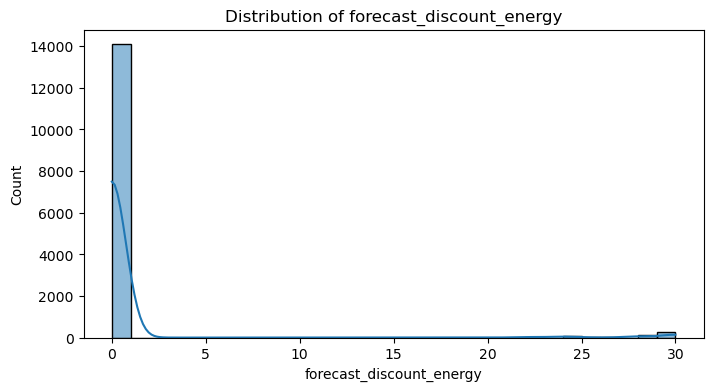

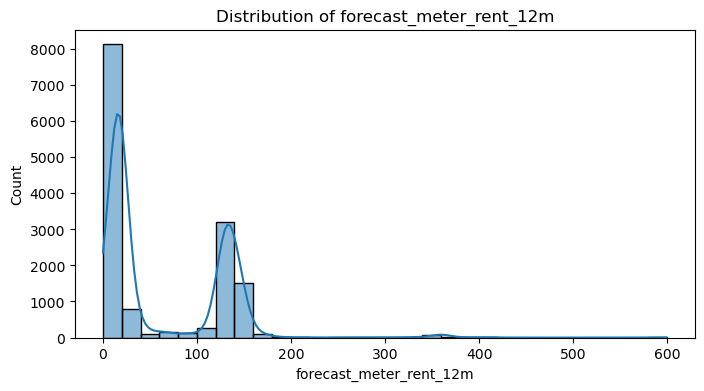

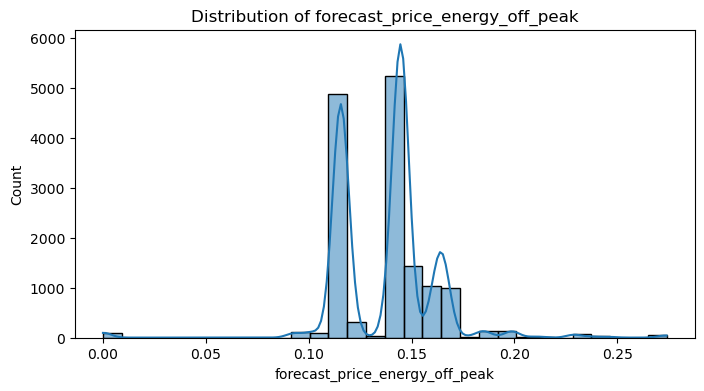

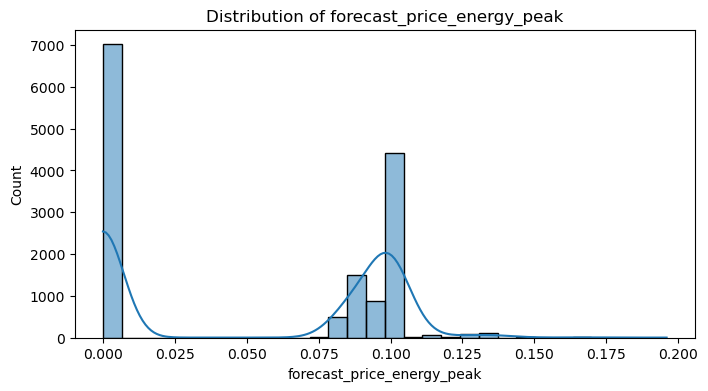

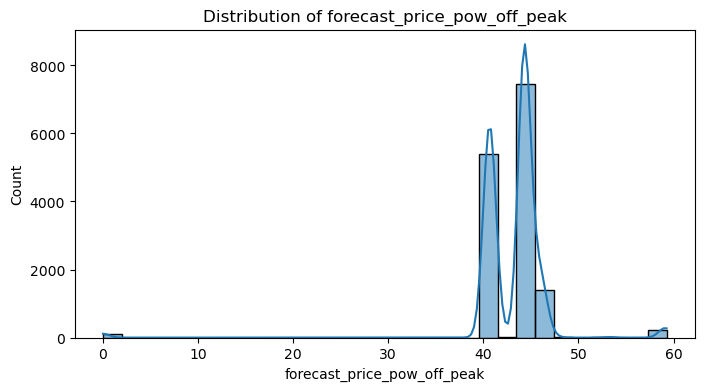

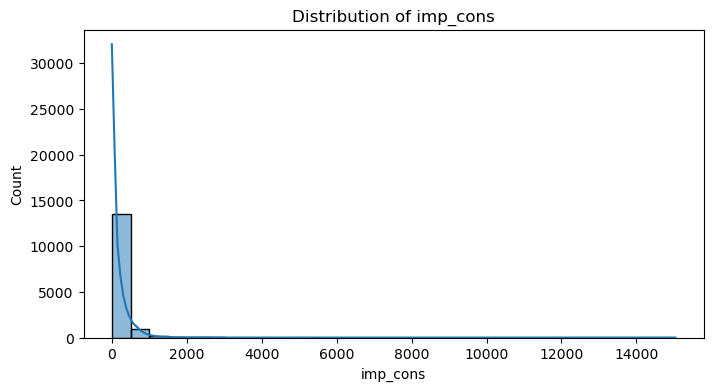

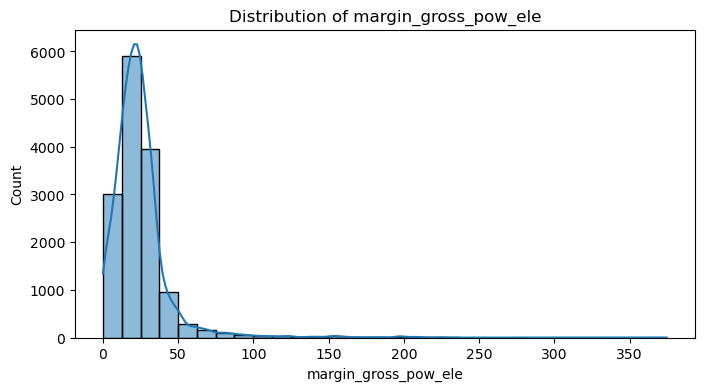

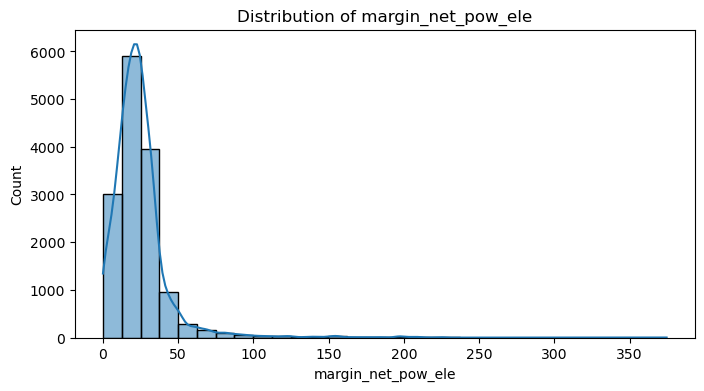

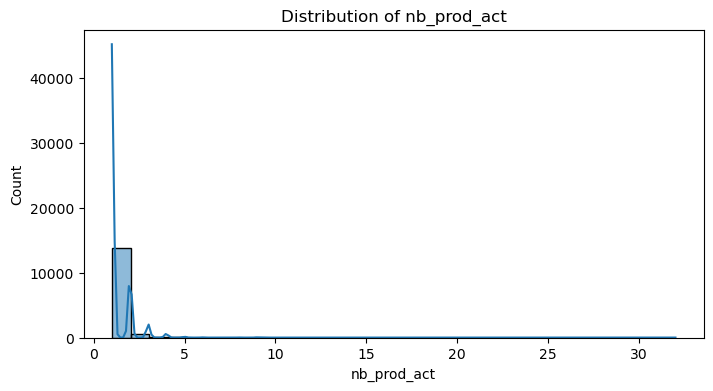

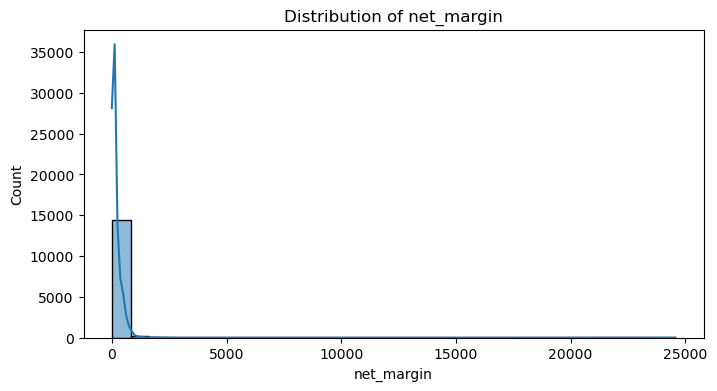

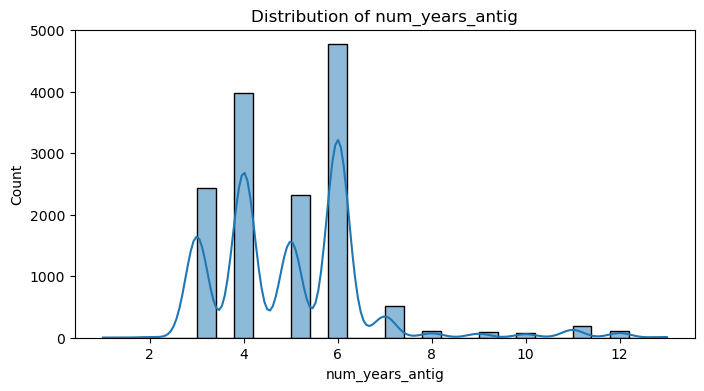

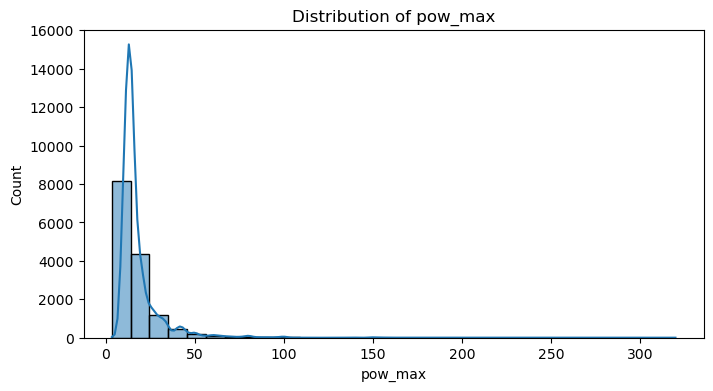

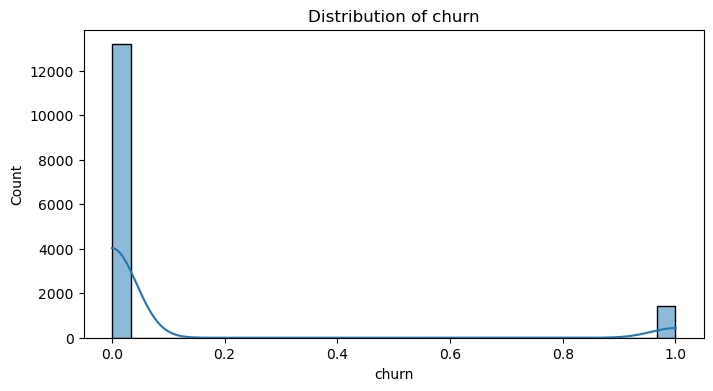


Churn Rate:
churn
0    0.902848
1    0.097152
Name: proportion, dtype: float64


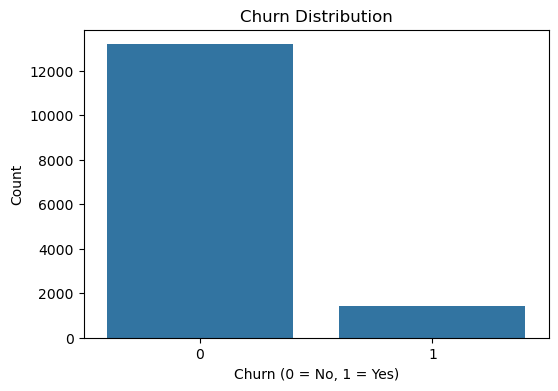

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
client_data = pd.read_csv('C:/Users/hp/Downloads/client_data (1) (1).csv')
price_data = pd.read_csv('C:/Users/hp/Downloads/price_data (1).csv')

# Display basic info about each dataset
print("Client Data Info:")
print(client_data.info())
print("\nPrice Data Info:")
print(price_data.info())

# Display descriptive statistics
print("\nClient Data Statistics:")
print(client_data.describe())
print("\nPrice Data Statistics:")
print(price_data.describe())

# Visualizing distributions for numeric columns
numeric_columns = client_data.select_dtypes(include=['number']).columns
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(client_data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Checking churn rate
churn_rate = client_data['churn'].value_counts(normalize=True)
print("\nChurn Rate:")
print(churn_rate)

# Visualizing churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=client_data['churn'])
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [21]:
import pandas as pd

# Load data
df = pd.read_csv('C:/Users/hp/Downloads/clean_data_after_eda.csv')

# Drop irrelevant columns
df = df.drop(columns=['id'])

# Expand date columns into separate features
df['month_activ'] = pd.to_datetime(df['date_activ']).dt.month
df['year_activ'] = pd.to_datetime(df['date_activ']).dt.year
df['day_of_week_activ'] = pd.to_datetime(df['date_activ']).dt.dayofweek
df['month_end'] = pd.to_datetime(df['date_end']).dt.month
df['year_end'] = pd.to_datetime(df['date_end']).dt.year
df['day_of_week_end'] = pd.to_datetime(df['date_end']).dt.dayofweek
df['month_modif_prod'] = pd.to_datetime(df['date_modif_prod']).dt.month
df['year_modif_prod'] = pd.to_datetime(df['date_modif_prod']).dt.year
df['day_of_week_modif_prod'] = pd.to_datetime(df['date_modif_prod']).dt.dayofweek

# Create new features by combining existing ones
df['total_forecast_price'] = df['forecast_price_energy_off_peak'] + df['forecast_price_energy_peak'] + df['forecast_price_pow_off_peak']
df['total_price_variation'] = df['var_year_price_off_peak'] + df['var_year_price_peak'] + df['var_year_price_mid_peak']

# Create ratio features
df['cons_ratio'] = df['cons_12m'] / df['forecast_cons_12m']
df['margin_ratio'] = df['margin_gross_pow_ele'] / df['net_margin']

# Handle missing values (example, replace with the median)
# Get numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Fill missing values in numeric columns with their median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in categorical columns with their mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])




# One-hot encode the 'has_gas' feature if necessary
# Ensure 'has_gas' is in a binary format (True/False or categorical)

# Convert 't' to 1 and 'f' to 0, then convert to integer
df['has_gas'] = df['has_gas'].map({'t': 1, 'f': 0}).astype(int)

# Save the processed data
df.to_csv('processed_data.csv', index=False)


In [5]:
df = pd.read_csv('C:/Users/hp/Downloads/clean_data_after_eda.csv')
print(df.columns)


Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max',
       'var_year_price_off_peak_var', 'var_year_price_peak_var',
       'var_year_price_mid_peak_var', 'var_year_price_off_peak_fix',
       'var_year_price_peak_fix', 'var_year_price_mid_peak_fix',
       'var_year_price_off_peak', 'var_year_price_peak',
       'var_year_price_mid_peak', 'var_6m_price_off_peak_var',
       'var_6m_price_peak_var', 'var_6m_price_mid_peak_var',
       'var_6m_price_off_peak_fix', 'var_6m_price_peak_fix',
       'var_6m_price_mid_peak_fix', 'var_6m_p

In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the dataset
df = pd.read_csv('C:/Users/hp/Downloads/data_for_predictions.csv')

# No need to convert 'has_gas' if it's already in 1 and 0
# df['has_gas'] = df['has_gas'].map({'t': 1, 'f': 0}).astype(int)

# Handle missing values (fill with median for numeric columns)


# Define X (features) and y (target)
X = df.drop(columns=['churn'])
y = df['churn'].astype(int)  # Ensure 'churn' is binary (0 or 1)

# Continue with the rest of the process...
# Get numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Fill missing values in numeric columns with their median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Define X (features) and y (target)
X = df.drop(columns=['churn'])
y = df['churn'].astype(int)  # Ensure 'churn' is binary (0 or 1)

# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop the 'id' column from the features as it's not relevant
X = X.drop(columns=['id'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure there are no missing values
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")

# Train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score
y_pred_prob = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC Score: {auc}")

# Predict on the test set
y_pred = rf.predict(X_test)

# Calculate the accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:")
print(conf_matrix)

# Evaluate model performance
if recall < 0.6:
    print("The model may not be performing well in detecting churn. Consider adjusting the model.")
else:
    print("The model is performing reasonably well.")


Missing values in X_train: 0
Missing values in y_train: 0
ROC-AUC Score: 0.6555215896064196
Accuracy: 0.9000684462696783
Precision: 0.8823529411764706
Recall: 0.04918032786885246
F1 Score: 0.09316770186335403
Confusion Matrix:
[[2615    2]
 [ 290   15]]
The model may not be performing well in detecting churn. Consider adjusting the model.


In [27]:
print(df['has_gas'].unique())

[1 0]
